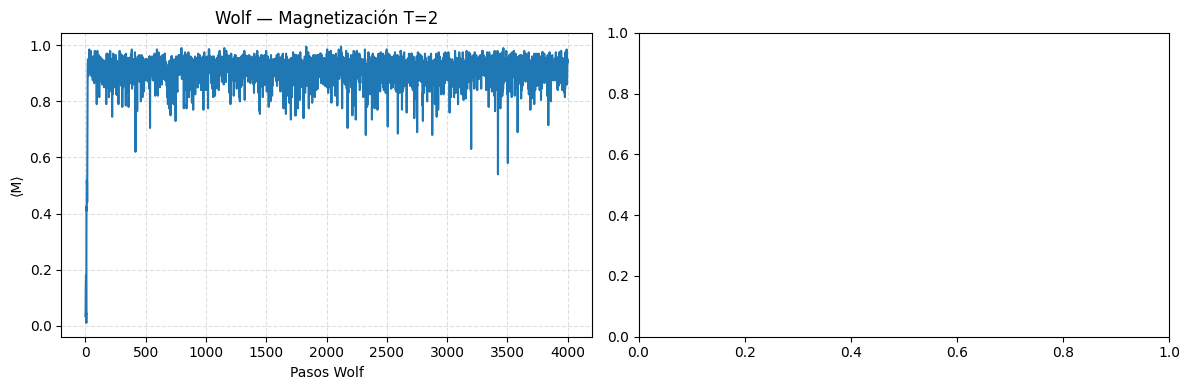

In [1]:
'''
Wolf Fixeado
'''


import numpy as np
import matplotlib.pyplot as plt

def generador_red_inicial(N, rng):
    return rng.choice([-1, 1], size=(N, N))

def simular_paso_wolf(red, J, beta, rng):
    N = red.shape[0]

    p_add = 1.0 - np.exp(-2.0 * beta * J)# Probabilidad de enlace (ec. 11 )
    '''
    revisar la teoría detras de esto ^
    '''

    i0, j0 = rng.integers(0, N, size=2)#guardamos dirección 
    s0 = red[i0, j0]  # dirección original del cluster

    # visitados: para no procesar el mismo spin dos veces
    cluster = [(i0, j0)]
    visitados = {(i0, j0)}
    pila = [(i0, j0)]

    while pila:
        ci, cj = pila.pop()
        # 4 vecinos con condiciones periódicas
        vecinos = [
            ((ci + 1) % N, cj), ((ci - 1) % N, cj),
            (ci, (cj + 1) % N), (ci, (cj - 1) % N)
        ]
        for ni, nj in vecinos:
            # 1. Comprobamos si coincide el espín y si no está ya en el clúster/pila
            if red[ni, nj] == s0 and (ni, nj) not in visitados:
                # 2. Si pasa la probabilidad, lo agregamos y lo bloqueamos
                if rng.random() < p_add:
                    visitados.add((ni, nj)) # Ahora 'visitados' significa 'dentro de la pila'
                    cluster.append((ni, nj))
                    pila.append((ni, nj))

    for ci, cj in cluster:#flipeamos el cluster completo de una
        red[ci, cj] *= -1

    return len(cluster)  

def ejecutar_wolf(N, J, T, n_inactivos, n_activos, semilla=None):
    semilla = semilla if semilla is not None else np.random.randint(0, 10**6)
    rng = np.random.default_rng(semilla)
    red = generador_red_inicial(N, rng)
    beta = 1.0 / T
    B = 0  # Wolf no admite campo externo B≠0 con esta formulación

    for _ in range(n_inactivos):
        simular_paso_wolf(red, J, beta, rng)

    m_hist, tam_cluster = [], []
    for _ in range(n_activos):
        tam = simular_paso_wolf(red, J, beta, rng)
        m_hist.append(np.abs(np.mean(red)))
        tam_cluster.append(tam)

    return red, np.array(m_hist), np.array(tam_cluster), semilla

# ---.................................................... CORRIDA DE PRUEBA ---------------------------------------------------------------------
N, J, T = 20, 1, 2  # menor a Tc = 2.269...
red_f, m_h, tam_h, s = ejecutar_wolf(N, J, T, n_inactivos=0, n_activos=4000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(m_h); ax1.set_xlabel('Pasos Wolf'); ax1.set_ylabel('⟨M⟩')
ax1.set_title(f'Wolf — Magnetización T={T}'); ax1.grid(True, ls='--', alpha=0.4)
'''
ax2.plot(tam_h, color='orange'); ax2.set_xlabel('Pasos Wolf')
ax2.set_ylabel('Tamaño del cluster'); ax2.set_title('Tamaño de cluster por paso')
ax2.grid(True, ls='--', alpha=0.4)
'''
plt.tight_layout(); plt.show()

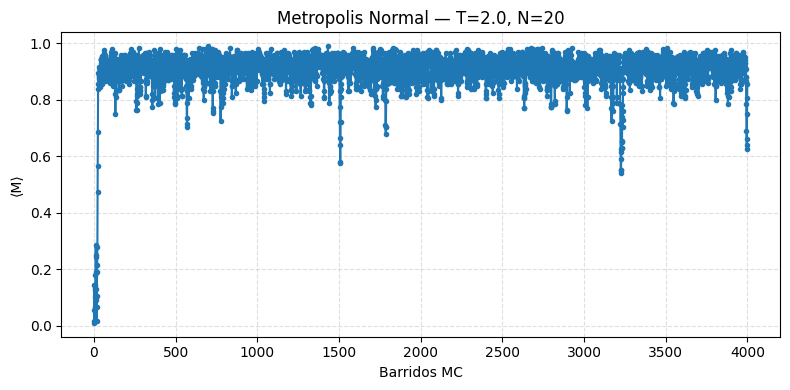

In [2]:
'''
Metropolis Vectorizado 
'''
import numpy as np
import matplotlib.pyplot as plt

def generador_red_inicial(N, rng):
    return rng.choice([-1, 1], size=(N, N))

def interaccion_local(red, J, B):
    suma_vecinos = (np.roll(red, 1, axis=0) + np.roll(red, -1, axis=0) +
                    np.roll(red, 1, axis=1) + np.roll(red, -1, axis=1))
    return 2 * red * (J * suma_vecinos + B)

def evaluar_metropolis(delta_e, beta, rng):
    prob = np.where(delta_e > 0, np.exp(-beta * delta_e), 1.0)
    return rng.random(size=delta_e.shape) < prob

def simular_paso_metro_vec(red, J, B, beta, rng):
    N = red.shape[0]
    ii, jj = np.indices((N, N))
    mascara_ajedrez = (ii + jj) % 2
    for color in [0, 1]:
        dE = interaccion_local(red, J, B)
        aceptados = evaluar_metropolis(dE, beta, rng)
        red[(mascara_ajedrez == color) & aceptados] *= -1

def ejecutar_metro_vec(N, J, B, T, n_inactivos, n_activos, semilla=None):
    semilla = semilla if semilla is not None else np.random.randint(0, 10**6)
    rng = np.random.default_rng(semilla)
    red = generador_red_inicial(N, rng)
    beta = 1.0 / T
    for _ in range(n_inactivos):
        simular_paso_metro_vec(red, J, B, beta, rng)
    m_hist, e_hist = [], []
    for _ in range(n_activos):
        simular_paso_metro_vec(red, J, B, beta, rng)
        m_hist.append(np.abs(np.mean(red)))
        # Energía por spin: suma de interacciones locales / (2*N²)
        # (factor 2 evita doble conteo de pares)
        sv = (np.roll(red,1,0)+np.roll(red,-1,0)+np.roll(red,1,1)+np.roll(red,-1,1))
        e_hist.append(-J * np.sum(red * sv) / (2 * N**2))
    return red, np.array(m_hist), np.array(e_hist), semilla


N, J, B, T = 20, 1, 0, 2.0#prueba del código
red_f, m_hist, e_hist, s = ejecutar_metro_vec(N, J, B, T, n_inactivos=0, n_activos=4000)

plt.figure(figsize=(8, 4))
plt.plot(m_hist, marker='o', ms=3, lw=1.5, label='Magnetización')
plt.xlabel('Barridos MC'); plt.ylabel('⟨M⟩')
plt.title(f'Metropolis Normal — T={T}, N={N}')
plt.grid(True, ls='--', alpha=0.4); plt.tight_layout(); plt.show()

In [3]:
'''
Metropolis 
'''

'''
import numpy as np
import matplotlib.pyplot as plt

def generador_red_inicial(N, rng):
    return rng.choice([-1, 1], size=(N, N))

def interaccion_local_scalar(red, i, j, J, B):
    N = red.shape[0]
    s_i = red[i, j]
    suma_vecinos = (red[(i+1)%N, j] + red[(i-1)%N, j] +
                    red[i, (j+1)%N] + red[i, (j-1)%N])
    return 2 * s_i * (J * suma_vecinos + B)

def evaluar_metropolis(delta_e, beta, rng):
    if delta_e <= 0: return True
    return rng.random() < np.exp(-beta * delta_e)

def simular_paso_montecarlo_normal(red, J, B, beta, rng):
    N = red.shape[0]
    for _ in range(N * N):
        i, j = rng.integers(0, N, size=2)
        dE = interaccion_local_scalar(red, i, j, J, B)
        if evaluar_metropolis(dE, beta, rng):
            red[i, j] *= -1

def ejecutar_experimento_normal(N, J, B, T, n_inactivos, n_activos, semilla=None):
    semilla_usada = semilla if semilla is not None else np.random.randint(0, 1000000)
    rng = np.random.default_rng(semilla_usada)
    red = generador_red_inicial(N, rng)
    beta = 1.0 / T
    for _ in range(n_inactivos):
        simular_paso_montecarlo_normal(red, J, B, beta, rng)
    m_puntos = []
    for _ in range(n_activos):
        simular_paso_montecarlo_normal(red, J, B, beta, rng)
        m_puntos.append(np.abs(np.mean(red)))
    return red, np.array(m_puntos), semilla_usada

N, J, B, T = 20, 1, 0, 2.0#prueba del codigo
red_f, m_hist, s = ejecutar_experimento_normal(N, J, B, T, n_inactivos=0, n_activos=4000)

plt.figure(figsize=(8, 4))
plt.plot(m_hist, marker='o', ms=3, lw=1.5, label='Magnetización')
plt.xlabel('Barridos MC'); plt.ylabel('⟨M⟩')
plt.title(f'Metropolis Normal — T={T}, N={N}')
plt.grid(True, ls='--', alpha=0.4); plt.tight_layout(); plt.show()
'''


#IMPORTANTE, SOLO DESCOMNETEN ESTA PARTE EN CASO DE QUERER OBSERVAR QUE FUNIONA BIEN EL MONTECARLO METROPOLIS SIMPLE PERO SI VAN A CORRER TODO EL CÓDIGO RECOMIENDO 
#COMENTARLO PARA EVITAR PROBLEMAS

"\nimport numpy as np\nimport matplotlib.pyplot as plt\n\ndef generador_red_inicial(N, rng):\n    return rng.choice([-1, 1], size=(N, N))\n\ndef interaccion_local_scalar(red, i, j, J, B):\n    N = red.shape[0]\n    s_i = red[i, j]\n    suma_vecinos = (red[(i+1)%N, j] + red[(i-1)%N, j] +\n                    red[i, (j+1)%N] + red[i, (j-1)%N])\n    return 2 * s_i * (J * suma_vecinos + B)\n\ndef evaluar_metropolis(delta_e, beta, rng):\n    if delta_e <= 0: return True\n    return rng.random() < np.exp(-beta * delta_e)\n\ndef simular_paso_montecarlo_normal(red, J, B, beta, rng):\n    N = red.shape[0]\n    for _ in range(N * N):\n        i, j = rng.integers(0, N, size=2)\n        dE = interaccion_local_scalar(red, i, j, J, B)\n        if evaluar_metropolis(dE, beta, rng):\n            red[i, j] *= -1\n\ndef ejecutar_experimento_normal(N, J, B, T, n_inactivos, n_activos, semilla=None):\n    semilla_usada = semilla if semilla is not None else np.random.randint(0, 1000000)\n    rng = np.random

In [4]:
def bootstrap_error(data, func=np.mean, n_boots=500, bloque=1):
    #n_boots: número de remuestreos y bloque: longitud del bloque para bootstrap

    n = len(data)
    n_bloques = n // bloque
    # Reorganizamos en bloques
    bloques = data[:n_bloques * bloque].reshape(n_bloques, bloque)
    estimates = []
    for _ in range(n_boots):
        # Remuestreaamos bloques con reemplazo
        idx = np.random.randint(0, n_bloques, size=n_bloques)
        muestra = bloques[idx].ravel()
        estimates.append(func(muestra))
    return np.std(estimates)
def calcular_autocorrelacion(serie, t_max=None):
    n = len(serie)
    if t_max is None: t_max = n // 4
    mean = np.mean(serie)
    var = np.var(serie)
    if var < 1e-12: return np.zeros(t_max)
    C = np.zeros(t_max)
    for t in range(t_max):
        C[t] = np.mean((serie[:n-t] - mean) * (serie[t:] - mean)) / var
    return C

def calcular_tau_int(C, umbral=0.01):
    tau = 0.5
    for ct in C[1:]:
        if ct < umbral: break
        tau += ct
    return tau

In [5]:
def analisis_termalizacion_metropolis(N, J, B, T, n_pasos_total, semilla=None):
    if semilla is None:
        semilla = np.random.SeedSequence().entropy
        
    rng = np.random.default_rng(semilla)
    red = generador_red_inicial(N, rng)
    beta = 1.0 / T

    m_serie, e_serie = [], []
    for _ in range(n_pasos_total):
        simular_paso_metro_vec(red, J, B, beta, rng)
        m_serie.append(np.abs(np.mean(red)))
        
        sv = (np.roll(red, 1, 0) + np.roll(red, -1, 0) + np.roll(red, 1, 1) + np.roll(red, -1, 1))
        e_serie.append(-J * np.sum(red * sv) / (2 * N**2))

    m_term = np.array(m_serie)[n_pasos_total // 2:]#Ventana termalizada
    e_term = np.array(e_serie)[n_pasos_total // 2:]

    C_autocorr = calcular_autocorrelacion(m_term, t_max=200)
    tau = calcular_tau_int(C_autocorr)
    bloque_dinamico = int(max(1, np.ceil(2 * tau)))

    magnitudes = {
        'M': np.mean(m_term), 
        'E': np.mean(e_term),
        'C': (np.mean(e_term**2) - np.mean(e_term)**2) / (T**2) * (N**2),
        'Chi': (np.mean(m_term**2) - np.mean(m_term)**2) / T * (N**2),
        'M2': np.mean(m_term**2),
        'M4': np.mean(m_term**4),
        'err_M': bootstrap_error(m_term, np.mean, bloque=bloque_dinamico),
        'err_E': bootstrap_error(e_term, np.mean, bloque=bloque_dinamico),
        'err_C': bootstrap_error(e_term, lambda x: (np.mean(x**2) - np.mean(x)**2) / T**2 * N**2, bloque=bloque_dinamico),
        'err_Chi': bootstrap_error(m_term, lambda x: (np.mean(x**2) - np.mean(x)**2) / T * N**2, bloque=bloque_dinamico)
    }
    return np.array(m_serie), C_autocorr, tau, magnitudes


def analisis_termalizacion_wolff(N, J, T, n_pasos_total, semilla=None):

    
    if semilla is None:
        semilla = np.random.SeedSequence().entropy
        
    rng = np.random.default_rng(semilla)
    red = generador_red_inicial(N, rng)
    beta = 1.0 / T

    m_serie, e_serie = [], []
    for _ in range(n_pasos_total):
        simular_paso_wolf(red, J, beta, rng)
        m_serie.append(np.abs(np.mean(red)))
        
        sv = (np.roll(red, 1, 0) + np.roll(red, -1, 0) + np.roll(red, 1, 1) + np.roll(red, -1, 1))
        e_serie.append(-J * np.sum(red * sv) / (2 * N**2))

    
    m_term = np.array(m_serie)[n_pasos_total // 2:]#Ventana termalizada
    e_term = np.array(e_serie)[n_pasos_total // 2:]

    C_autocorr = calcular_autocorrelacion(m_term, t_max=200)
    tau = calcular_tau_int(C_autocorr)
    bloque_dinamico = int(max(1, np.ceil(2 * tau)))

    magnitudes = {
        'M': np.mean(m_term), 
        'E': np.mean(e_term),
        'C': (np.mean(e_term**2) - np.mean(e_term)**2) / (T**2) * (N**2),
        'M2': np.mean(m_term**2),
        'M4': np.mean(m_term**4),
        'Chi': (np.mean(m_term**2) - np.mean(m_term)**2) / T * (N**2),
        'err_M': bootstrap_error(m_term, np.mean, bloque=bloque_dinamico),
        'err_E': bootstrap_error(e_term, np.mean, bloque=bloque_dinamico),
        'err_C': bootstrap_error(e_term, lambda x: (np.mean(x**2) - np.mean(x)**2) / T**2 * N**2, bloque=bloque_dinamico),
        'err_Chi': bootstrap_error(m_term, lambda x: (np.mean(x**2) - np.mean(x)**2) / T * N**2, bloque=bloque_dinamico)
    }
    return np.array(m_serie), C_autocorr, tau, magnitudes

In [6]:
'''
GENERACIÓN DE DATOS PARA FSS 
'''
#tamaños de red a simular
tamanos_red = [10, 20, 40, 80]

#ventana de temperatura más fina y enfocada alrededor de Tc
temperaturas_fss = np.linspace(2.15, 2.40, 15)

dict_T = {}
dict_M2 = {}
dict_M4 = {}

for L in tamanos_red:
    print(f"Simulando malla L={L}...")
    T_list, M2_list, M4_list = [], [], []
    
    for T in temperaturas_fss:
        _, _, _, mags = analisis_termalizacion_wolff(
            N=L, J=1, T=T, n_pasos_total=3000, semilla=None
        )
        
        T_list.append(T)
        M2_list.append(mags['M2'])
        M4_list.append(mags['M4'])
        
    #Guardamos las listas en los diccionarios usando L como llave
    dict_T[L] = T_list
    dict_M2[L] = M2_list
    dict_M4[L] = M4_list

print("Datos generados")

Simulando malla L=10...
Simulando malla L=20...
Simulando malla L=40...
Simulando malla L=80...
Datos generados


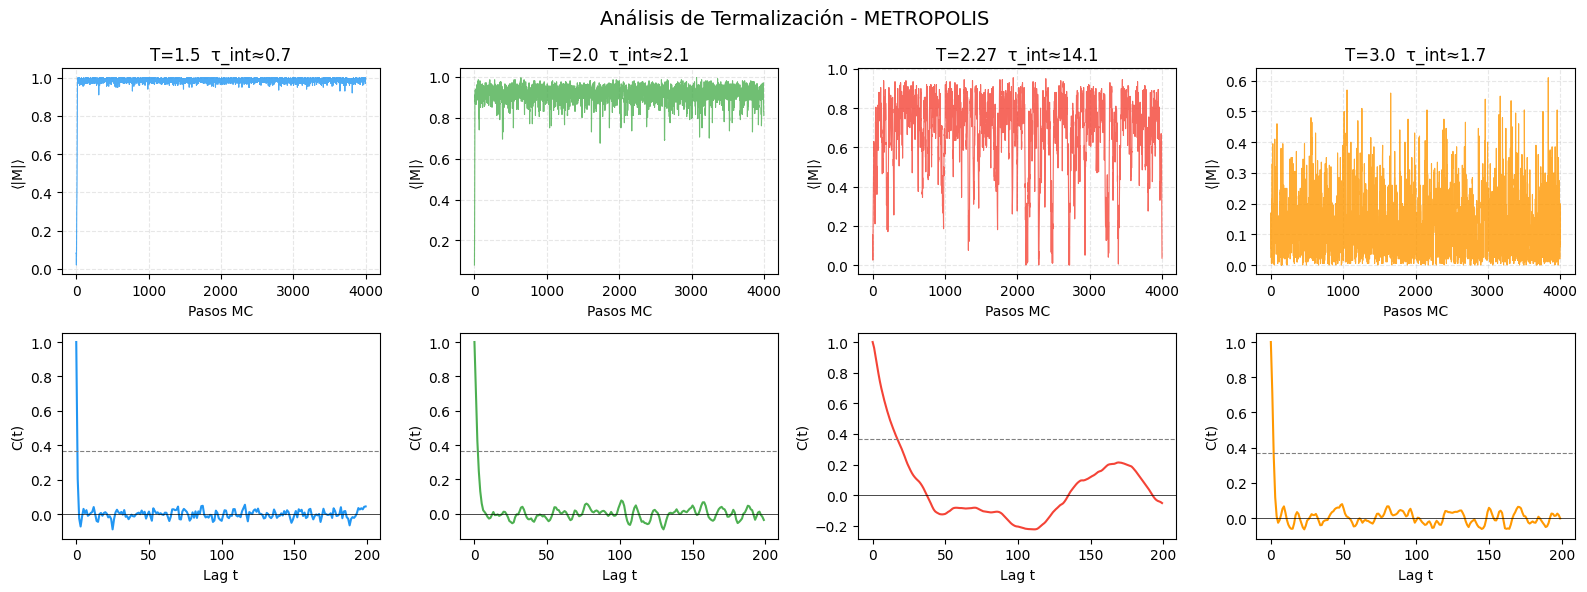

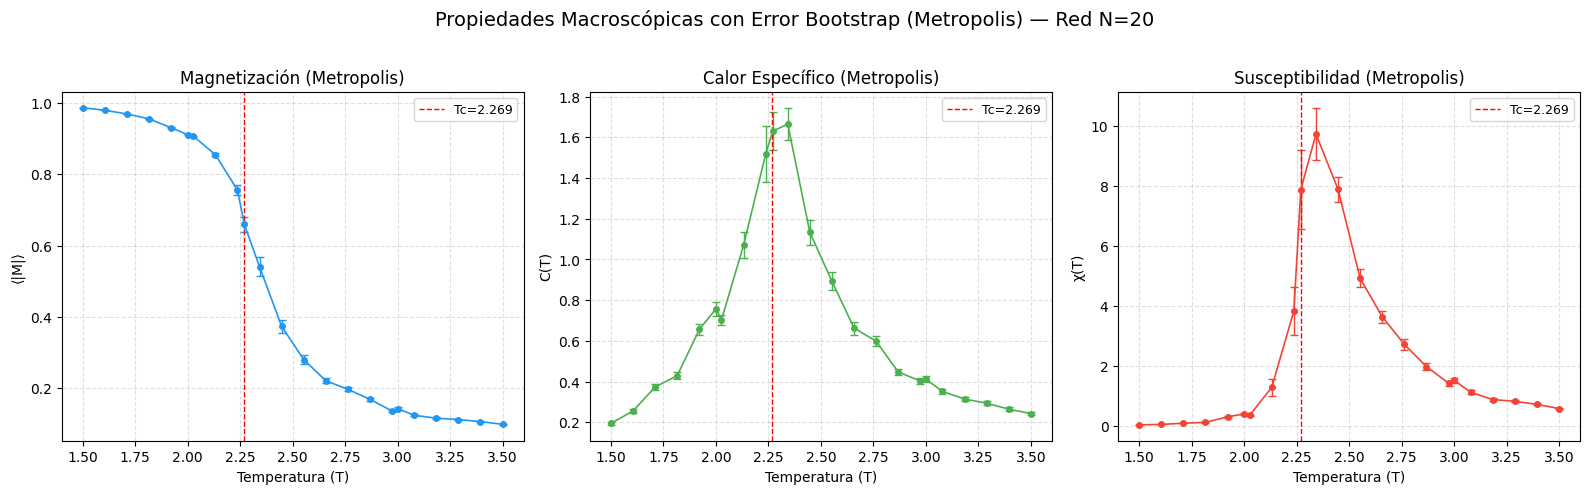

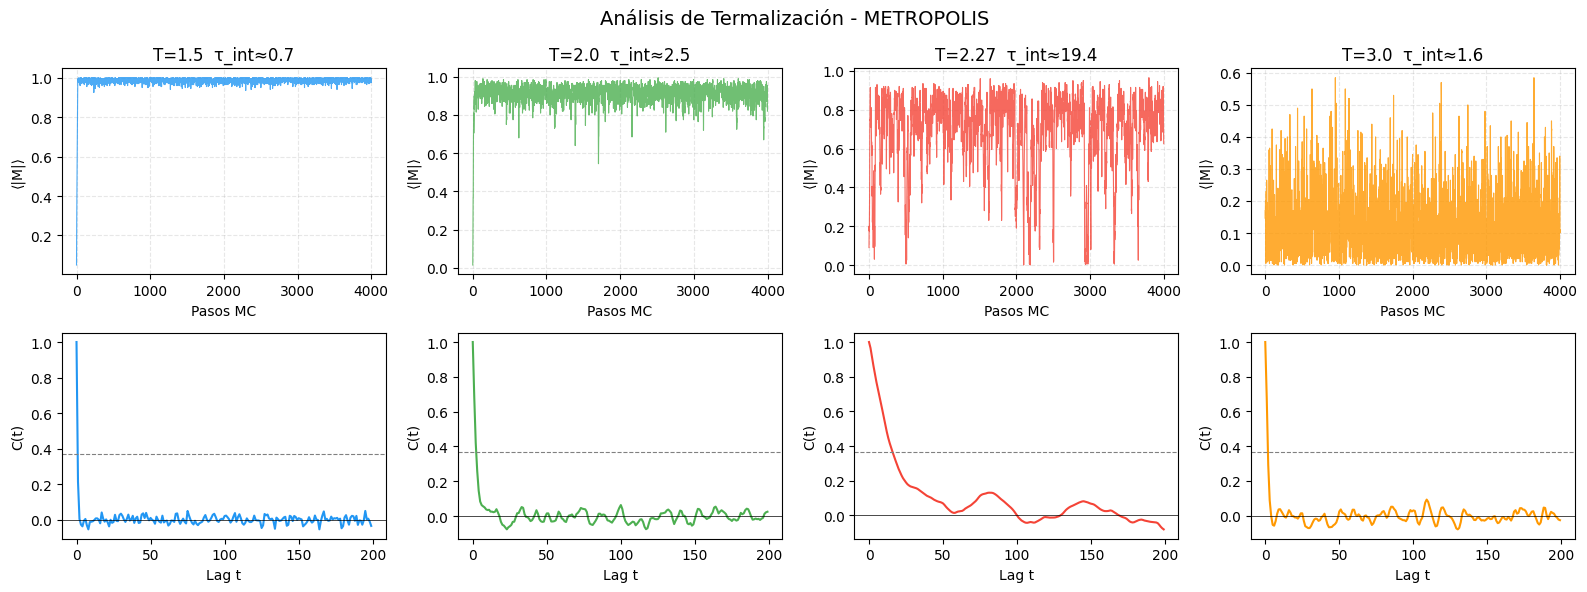

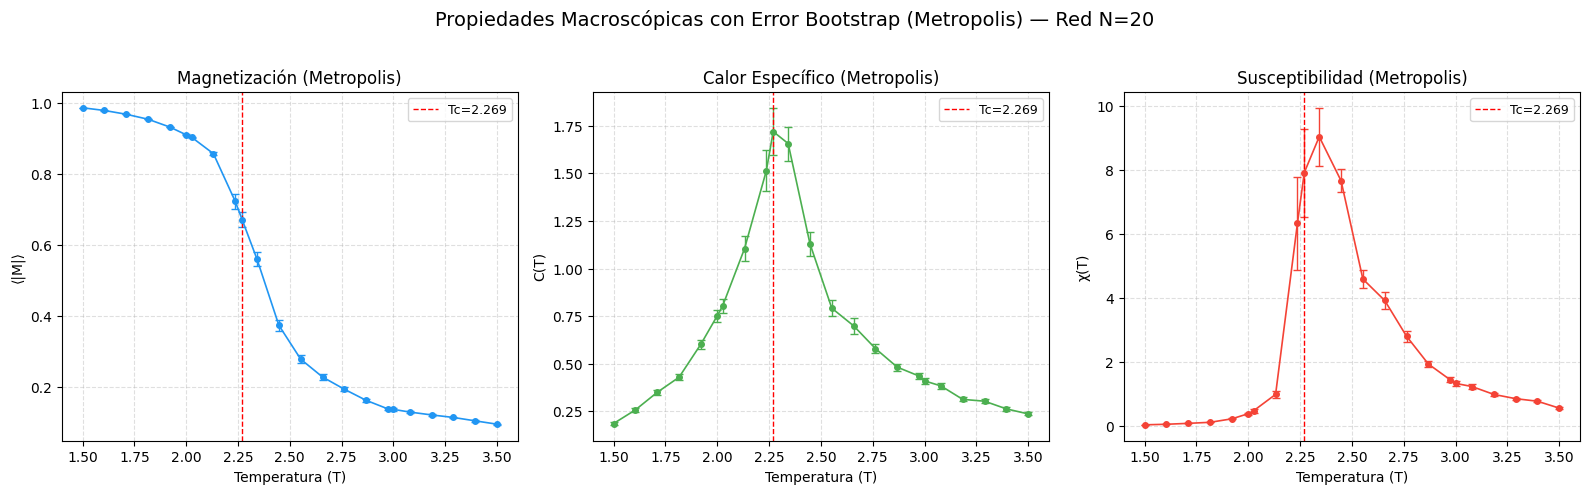

In [7]:
'''
Metropolis Completa (error, booststrap, etc)
'''


N, J, B = 20, 1, 0
PASOS_MC = 4000       
SEMILLA_FIJA = None  

Tc_onsager = 2.2692
temperaturas_test = np.unique(np.concatenate([np.linspace(1.5, 3.5, 20), [1.5, 2.0, 2.27, 3.0]])); temperaturas_test.sort()
puntos_control = {1.5: '#2196F3', 2.0: '#4CAF50', 2.27: '#F44336', 3.0: '#FF9800'}

M_vals, eM, C_vals, eC, chi_vals, echi = [], [], [], [], [], []

fig_term, axes_term = plt.subplots(2, 4, figsize=(16, 6))
fig_term.suptitle('Análisis de Termalización - METROPOLIS', fontsize=14)

col_idx = 0
for T in temperaturas_test:

    seed_actual = SEMILLA_FIJA + int(T*100) if SEMILLA_FIJA is not None else None# Si la semilla elegida es un número, usamos una semilla derivada por temperatura para no repetir estados.
    
    m_serie, C_autocorr, tau, mags = analisis_termalizacion_metropolis(
        N, J, B, T, n_pasos_total=PASOS_MC, semilla=seed_actual
    )
    
    M_vals.append(mags['M']); eM.append(mags['err_M'])
    C_vals.append(mags['C']); eC.append(mags['err_C'])
    chi_vals.append(mags['Chi']); echi.append(mags['err_Chi'])
    
    if T in puntos_control:
        color = puntos_control[T]
        axes_term[0, col_idx].plot(m_serie, lw=0.8, color=color, alpha=0.8)
        axes_term[0, col_idx].set_title(f'T={T}  τ_int≈{tau:.1f}')
        axes_term[0, col_idx].set_xlabel('Pasos MC'); axes_term[0, col_idx].set_ylabel('⟨|M|⟩')
        axes_term[0, col_idx].grid(True, ls='--', alpha=0.3)
        axes_term[1, col_idx].plot(C_autocorr, color=color)
        axes_term[1, col_idx].axhline(y=0, color='k', lw=0.5); axes_term[1, col_idx].axhline(y=1/np.e, color='gray', ls='--', lw=0.8)
        axes_term[1, col_idx].set_xlabel('Lag t'); axes_term[1, col_idx].set_ylabel('C(t)')
        col_idx += 1
plt.tight_layout(); plt.show()

# Gráficas macroscópicas con sus errores
M_vals, eM, C_vals, eC, chi_vals, echi = map(np.array, [M_vals, eM, C_vals, eC, chi_vals, echi])
fig_mags, axes_mags = plt.subplots(1, 3, figsize=(16, 4.8))
kw = dict(fmt='o-', ms=4, capsize=3, lw=1.2, elinewidth=1)

axes_mags[0].errorbar(temperaturas_test, M_vals, yerr=eM, color='#2196F3', **kw)
axes_mags[0].set_ylabel('⟨|M|⟩'); axes_mags[0].set_title('Magnetización (Metropolis)')
axes_mags[1].errorbar(temperaturas_test, C_vals, yerr=eC, color='#4CAF50', **kw)
axes_mags[1].set_ylabel('C(T)'); axes_mags[1].set_title('Calor Específico (Metropolis)')
axes_mags[2].errorbar(temperaturas_test, chi_vals, yerr=echi, color='#F44336', **kw)
axes_mags[2].set_ylabel('χ(T)'); axes_mags[2].set_title('Susceptibilidad (Metropolis)')

for ax in axes_mags:
    ax.axvline(Tc_onsager, color='red', ls='--', lw=1, label=f'Tc={Tc_onsager:.3f}')
    ax.set_xlabel('Temperatura (T)'); ax.grid(True, ls='--', alpha=0.4); ax.legend(fontsize=9)
plt.suptitle(f'Propiedades Macroscópicas con Error Bootstrap (Metropolis) — Red N={N}', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
SEMILLA_FIJA = None  

Tc_onsager = 2.2692
temperaturas_test = np.unique(np.concatenate([np.linspace(1.5, 3.5, 20), [1.5, 2.0, 2.27, 3.0]])); temperaturas_test.sort()
puntos_control = {1.5: '#2196F3', 2.0: '#4CAF50', 2.27: '#F44336', 3.0: '#FF9800'}

M_vals, eM, C_vals, eC, chi_vals, echi = [], [], [], [], [], []

fig_term, axes_term = plt.subplots(2, 4, figsize=(16, 6))
fig_term.suptitle('Análisis de Termalización - METROPOLIS', fontsize=14)

col_idx = 0
for T in temperaturas_test:

    seed_actual = SEMILLA_FIJA + int(T*100) if SEMILLA_FIJA is not None else None# Si la semilla elegida es un número, usamos una semilla derivada por temperatura para no repetir estados.
    
    m_serie, C_autocorr, tau, mags = analisis_termalizacion_metropolis(
        N, J, B, T, n_pasos_total=PASOS_MC, semilla=seed_actual
    )
    
    M_vals.append(mags['M']); eM.append(mags['err_M'])
    C_vals.append(mags['C']); eC.append(mags['err_C'])
    chi_vals.append(mags['Chi']); echi.append(mags['err_Chi'])
    
    if T in puntos_control:
        color = puntos_control[T]
        axes_term[0, col_idx].plot(m_serie, lw=0.8, color=color, alpha=0.8)
        axes_term[0, col_idx].set_title(f'T={T}  τ_int≈{tau:.1f}')
        axes_term[0, col_idx].set_xlabel('Pasos MC'); axes_term[0, col_idx].set_ylabel('⟨|M|⟩')
        axes_term[0, col_idx].grid(True, ls='--', alpha=0.3)
        axes_term[1, col_idx].plot(C_autocorr, color=color)
        axes_term[1, col_idx].axhline(y=0, color='k', lw=0.5); axes_term[1, col_idx].axhline(y=1/np.e, color='gray', ls='--', lw=0.8)
        axes_term[1, col_idx].set_xlabel('Lag t'); axes_term[1, col_idx].set_ylabel('C(t)')
        col_idx += 1
plt.tight_layout(); plt.show()

# Gráficas macroscópicas con sus errores
M_vals, eM, C_vals, eC, chi_vals, echi = map(np.array, [M_vals, eM, C_vals, eC, chi_vals, echi])
fig_mags, axes_mags = plt.subplots(1, 3, figsize=(16, 4.8))
kw = dict(fmt='o-', ms=4, capsize=3, lw=1.2, elinewidth=1)

axes_mags[0].errorbar(temperaturas_test, M_vals, yerr=eM, color='#2196F3', **kw)
axes_mags[0].set_ylabel('⟨|M|⟩'); axes_mags[0].set_title('Magnetización (Metropolis)')
axes_mags[1].errorbar(temperaturas_test, C_vals, yerr=eC, color='#4CAF50', **kw)
axes_mags[1].set_ylabel('C(T)'); axes_mags[1].set_title('Calor Específico (Metropolis)')
axes_mags[2].errorbar(temperaturas_test, chi_vals, yerr=echi, color='#F44336', **kw)
axes_mags[2].set_ylabel('χ(T)'); axes_mags[2].set_title('Susceptibilidad (Metropolis)')

for ax in axes_mags:
    ax.axvline(Tc_onsager, color='red', ls='--', lw=1, label=f'Tc={Tc_onsager:.3f}')
    ax.set_xlabel('Temperatura (T)'); ax.grid(True, ls='--', alpha=0.4); ax.legend(fontsize=9)
plt.suptitle(f'Propiedades Macroscópicas con Error Bootstrap (Metropolis) — Red N={N}', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

    RESULTADOS DE MAGNITUDES Y ERRORES CON WOLF (BOOTSTRAP) 
T      | ⟨|M|⟩ ± err     | ⟨E⟩ ± err       | C(T) ± err      | χ(T) ± err      | τ_int 
------------------------------------------------------------------------------------------
1.50   | 0.986±0.000 | -1.950±0.001 | 0.194±0.007 | 0.026±0.001 | 0.6   
2.00   | 0.913±0.001 | -1.749±0.002 | 0.739±0.027 | 0.365±0.025 | 0.9   
2.27   | 0.701±0.007 | -1.449±0.005 | 1.441±0.067 | 5.575±0.377 | 2.1   
3.00   | 0.129±0.005 | -0.816±0.005 | 0.337±0.029 | 1.337±0.099 | 3.5   


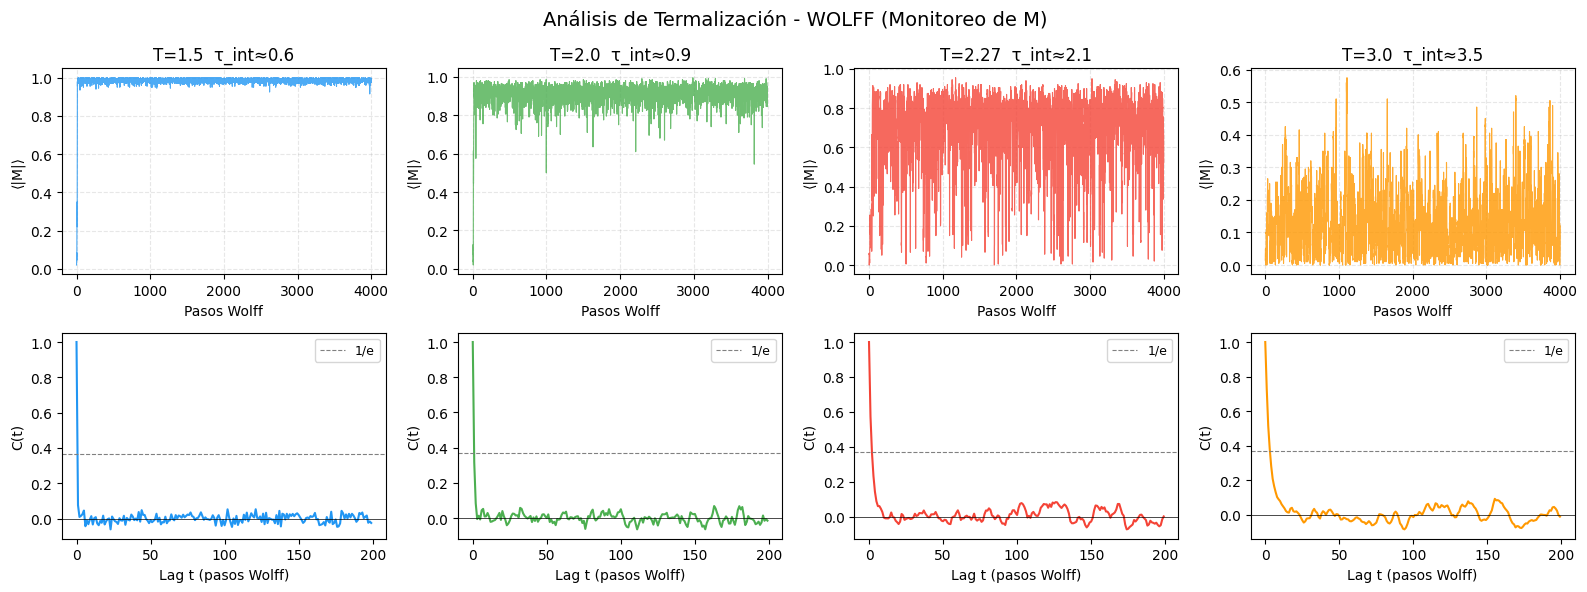

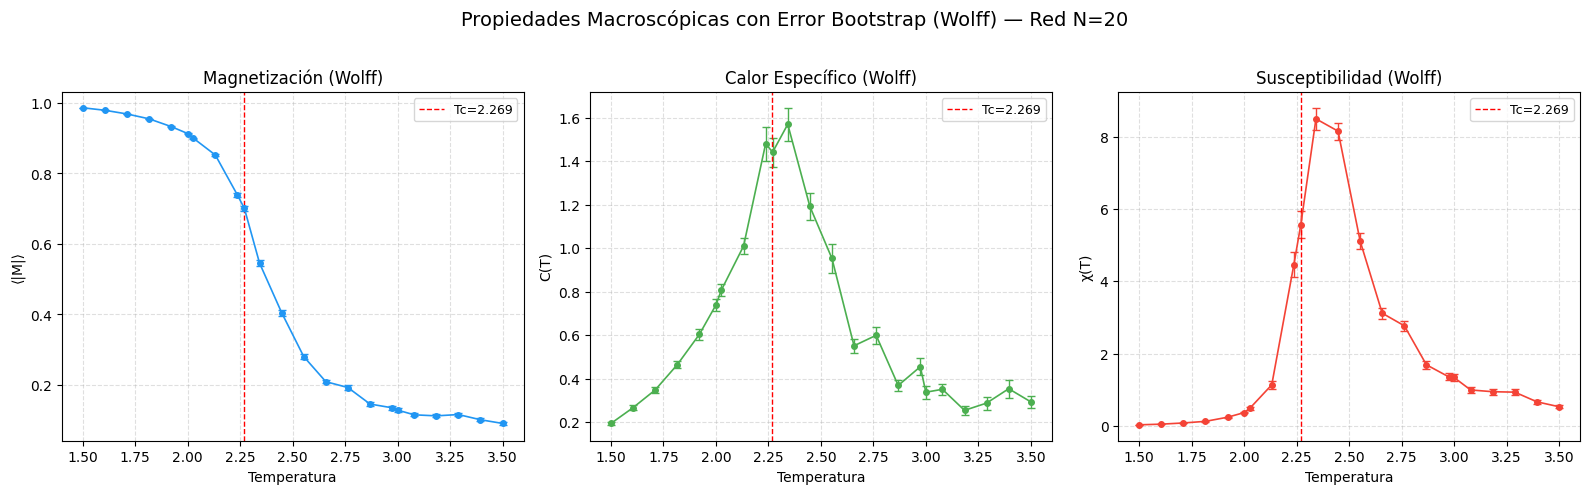

In [8]:

'''
Wolf Completa (error, booststrap, etc)
'''

PASOS_WOLFF = 4000       
SEMILLA_WOLFF = None       
N, J = 20, 1             



Tc_onsager = 2.2692#Que sabemos es obtenible de manera analitica
temperaturas_test = np.unique(np.concatenate([np.linspace(1.5, 3.5, 20), [1.5, 2.0, 2.27, 3.0]]))
temperaturas_test.sort()
puntos_control = {1.5: '#2196F3', 2.0: '#4CAF50', 2.27: '#F44336', 3.0: '#FF9800'}

M_vals, eM, C_vals, eC, chi_vals, echi = [], [], [], [], [], []

#Monitoreo de la termalización
fig_term, axes_term = plt.subplots(2, 4, figsize=(16, 6))
fig_term.suptitle('Análisis de Termalización - WOLFF (Monitoreo de M)', fontsize=14)

print("    RESULTADOS DE MAGNITUDES Y ERRORES CON WOLF (BOOTSTRAP) ")
print(f"{'T':<6} | {'⟨|M|⟩ ± err':<15} | {'⟨E⟩ ± err':<15} | {'C(T) ± err':<15} | {'χ(T) ± err':<15} | {'τ_int':<6}")
print("-" * 90)

col_idx = 0
for T in temperaturas_test:
    seed_actual = SEMILLA_WOLFF + int(T*100) if SEMILLA_WOLFF is not None else None
    
    m_serie, C_autocorr, tau, mags = analisis_termalizacion_wolff(
        N, J, T, n_pasos_total=PASOS_WOLFF, semilla=seed_actual# Llamamos a la función de análisis de Wolff
    )
    
    M_vals.append(mags['M']); eM.append(mags['err_M'])# Guardamos los resultados para las curvas de barrido macroscópico
    C_vals.append(mags['C']); eC.append(mags['err_C'])
    chi_vals.append(mags['Chi']); echi.append(mags['err_Chi'])
    
    # Graficamos e imprimimos solo si coincide con los puntos de control seleccionados
    if T in puntos_control:
        color = puntos_control[T]
        print(f"{T:<6.2f} | "
              f"{mags['M']:>5.3f}±{mags['err_M']:.3f} | "
              f"{mags['E']:>5.3f}±{mags['err_E']:.3f} | "
              f"{mags['C']:>5.3f}±{mags['err_C']:.3f} | "
              f"{mags['Chi']:>5.3f}±{mags['err_Chi']:.3f} | "
              f"{tau:<6.1f}")
        
        # Fila 1 para evolución temporal de |M|
        axes_term[0, col_idx].plot(m_serie, lw=0.8, color=color, alpha=0.8)
        axes_term[0, col_idx].set_title(f'T={T}  τ_int≈{tau:.1f}')
        axes_term[0, col_idx].set_xlabel('Pasos Wolff'); axes_term[0, col_idx].set_ylabel('⟨|M|⟩')
        axes_term[0, col_idx].grid(True, ls='--', alpha=0.3)

        # Fila 2 para l función de autocorrelación
        axes_term[1, col_idx].plot(C_autocorr, color=color)
        axes_term[1, col_idx].axhline(y=0, color='k', lw=0.5)
        axes_term[1, col_idx].axhline(y=1/np.e, color='gray', ls='--', lw=0.8, label='1/e')
        axes_term[1, col_idx].set_xlabel('Lag t (pasos Wolff)'); axes_term[1, col_idx].set_ylabel('C(t)')
        axes_term[1, col_idx].legend(fontsize=9)
        col_idx += 1

plt.tight_layout()
plt.show()


# Gráficas macroscópicas con barras de error
M_vals, eM, C_vals, eC, chi_vals, echi = map(np.array, [M_vals, eM, C_vals, eC, chi_vals, echi])
fig_mags, axes_mags = plt.subplots(1, 3, figsize=(16, 4.8))
kw = dict(fmt='o-', ms=4, capsize=3, lw=1.2, elinewidth=1)

axes_mags[0].errorbar(temperaturas_test, M_vals, yerr=eM, color='#2196F3', **kw)
axes_mags[0].set_ylabel('⟨|M|⟩'); axes_mags[0].set_title('Magnetización (Wolff)')
axes_mags[1].errorbar(temperaturas_test, C_vals, yerr=eC, color='#4CAF50', **kw)
axes_mags[1].set_ylabel('C(T)'); axes_mags[1].set_title('Calor Específico (Wolff)')
axes_mags[2].errorbar(temperaturas_test, chi_vals, yerr=echi, color='#F44336', **kw)
axes_mags[2].set_ylabel('χ(T)'); axes_mags[2].set_title('Susceptibilidad (Wolff)')

for ax in axes_mags:
    ax.axvline(Tc_onsager, color='red', ls='--', lw=1, label=f'Tc={Tc_onsager:.3f}')
    ax.set_xlabel('Temperatura'); ax.grid(True, ls='--', alpha=0.4); ax.legend(fontsize=9)
plt.suptitle(f'Propiedades Macroscópicas con Error Bootstrap (Wolff) — Red N={N}', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

<>:113: SyntaxWarning: invalid escape sequence '\l'
<>:114: SyntaxWarning: invalid escape sequence '\l'
<>:113: SyntaxWarning: invalid escape sequence '\l'
<>:114: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_257440/3398970010.py:113: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel('$\ln(L)$')
/tmp/ipykernel_257440/3398970010.py:114: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_ylabel('$\ln(|dU_L/dT|)$ en $T_c$')


Temperatura crítica estimada (Tc): 2.27263
----------------------------------------
RESULTADOS DEL FINITE-SIZE SCALING:
Pendiente ajustada (1/nu): 0.95407 +/- 0.03807
Exponente crítico nu obtenido: 1.04814 +/- 0.04183
R-cuadrado del ajuste: 0.99683
----------------------------------------


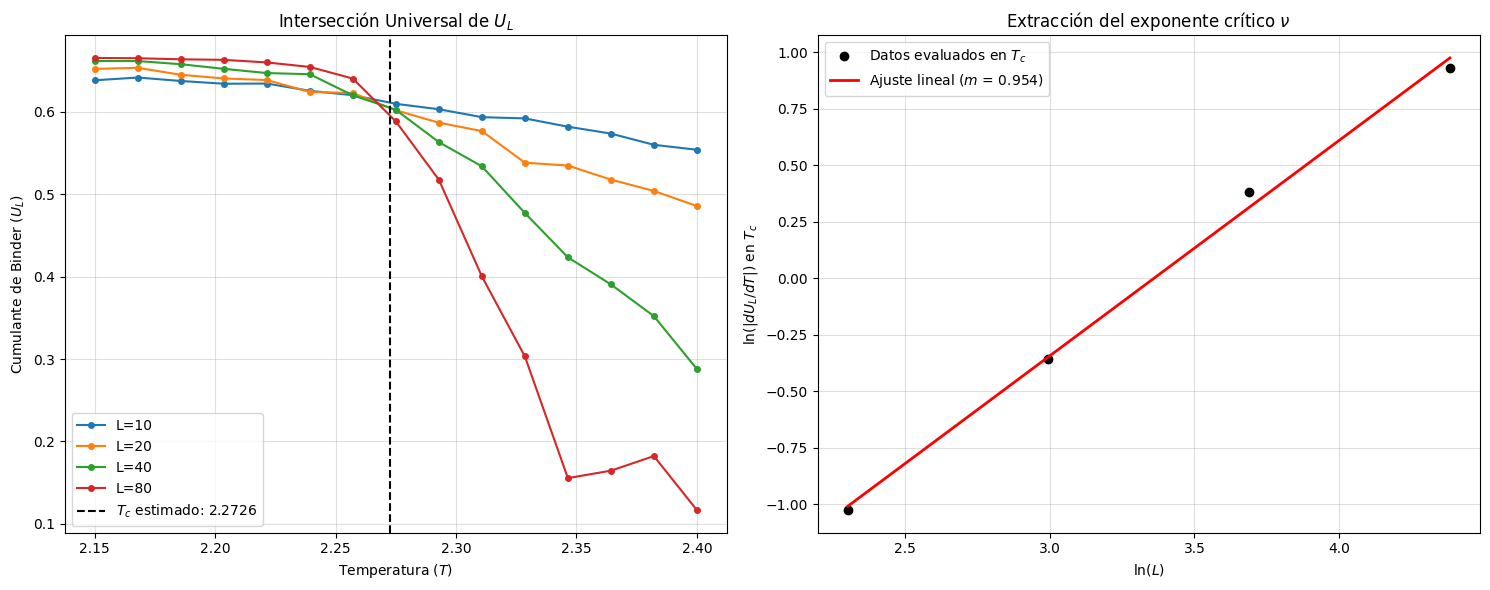

In [9]:

'''
OBTENCIÓN DEL EXPONENTE CRÍTICO
'''

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


#PREPARACIÓN Y CÁLCULO DEL CUMULANTE DE BINDER
tamanos_L = [10, 20, 40, 80] 

# Diccionarios para almacenar las variables clave por tamaño de red
T_arrays = {}
U_arrays = {}

for L in tamanos_L:
    T_L = np.array(dict_T[L])  
    M2_L = np.array(dict_M2[L])            
    M4_L = np.array(dict_M4[L])          
    
    #cumulante de 4to orden de Binder
    U_L = 1.0 - (M4_L / (3.0 * (M2_L ** 2)))
    
    T_arrays[L] = T_L
    U_arrays[L] = U_L

#INTERSECCIÓN DE U_L
L_A, L_B = tamanos_L[-2], tamanos_L[-1]#L=40 y L=80 respectivamente

# Ajuste polinómico alrededor de temperatura crítica
grado_poly = 6
coefs_A = np.polyfit(T_arrays[L_A], U_arrays[L_A], grado_poly)
coefs_B = np.polyfit(T_arrays[L_B], U_arrays[L_B], grado_poly)

poly_A = np.poly1d(coefs_A)
poly_B = np.poly1d(coefs_B)

#encontrar raíces de la diferencia de los dos polinomios
diferencia_poly = poly_A - poly_B
raices = diferencia_poly.roots

#filtramos la raíz que sea real y caiga dentro de nuestro rango de T
T_min, T_max = np.min(T_arrays[L_A]), np.max(T_arrays[L_A])
raices_validas = [r.real for r in raices if np.isreal(r) and T_min <= r.real <= T_max]

Tc_estimada = raices_validas[0]
print(f"Temperatura crítica estimada (Tc): {Tc_estimada:.5f}")

#DERIVADA POLINÓMICA LOCAL Y EXTRACCIÓN DE NU
derivadas_Tc = []


ventana_T = 0.3 

for L in tamanos_L:
    T = T_arrays[L]
    U = U_arrays[L]
    
    #tomar solo los datos que están en la vecindad de Tc
    mascara = (T >= Tc_estimada - ventana_T) & (T <= Tc_estimada + ventana_T)
    T_local = T[mascara]
    U_local = U[mascara]
    
    #Ajuste polinómico de grado dos en la localidad de T_c
    coefs_locales = np.polyfit(T_local, U_local, 2)
    poly_local = np.poly1d(coefs_locales)
    
    #Derivación analítica del polinomio local
    derivada_poly = np.polyder(poly_local)
    
    #Evaluamos la derivada exactamente en el Tc que encontramos antes
    dU_dT = derivada_poly(Tc_estimada)
    derivadas_Tc.append(np.abs(dU_dT))

derivadas_Tc = np.array(derivadas_Tc)

#AJUSTE LOG-LOG 
log_L = np.log(tamanos_L)
log_dU = np.log(derivadas_Tc)

#Regresión lineal por mínimos cuadrados
slope, intercept, r_value, p_value, std_err = linregress(log_L, log_dU)

#El exponente crítico nu es el inverso de la pendiente del ajuste
nu_estimado = 1.0 / slope
error_nu = std_err / (slope ** 2)

print("-" * 40)
print("RESULTADOS DEL FINITE-SIZE SCALING:")
print(f"Pendiente ajustada (1/nu): {slope:.5f} +/- {std_err:.5f}")
print(f"Exponente crítico nu obtenido: {nu_estimado:.5f} +/- {error_nu:.5f}")
print(f"R-cuadrado del ajuste: {r_value**2:.5f}")
print("-" * 40)

#VISUALIZACIÓN DE LOS RESULTADOS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Gráfico1:Cumulante de Binder
for L in tamanos_L:
    ax1.plot(T_arrays[L], U_arrays[L], 'o-', label=f'L={L}', markersize=4)
ax1.axvline(Tc_estimada, color='black', linestyle='--', label=f'$T_c$ estimado: {Tc_estimada:.4f}')
ax1.set_xlabel('Temperatura')
ax1.set_ylabel('Cumulante de Binder ($U_L$)')
ax1.set_title('Intersección Universal de $U_L$')
ax1.legend()
ax1.grid(alpha=0.4)

#Gráfico2:Ajuste Lineal Log-Log
ax2.plot(log_L, log_dU, 'ko', label='Datos evaluados en $T_c$', markersize=6)
ax2.plot(log_L, slope * log_L + intercept, 'r-', linewidth=2, label=f'Ajuste lineal ($m$ = {slope:.3f})')
ax2.set_xlabel('$\ln(L)$')
ax2.set_ylabel('$\ln(|dU_L/dT|)$ en $T_c$')
ax2.set_title('Extracción del exponente crítico $\\nu$')
ax2.legend()
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
'''
ANIMACIÓN DE DOMINIOS MAGNÉTICOS CON WOLFF
'''
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

T_min = 0.5                
T_max = 3.0               

N = 360                     
J = 1.0
n_temp = 60                # Número de pasos de temperatura en el barrido
pasos_por_temp = 8         #Pasos de Wolff por cada temperatura
intervalo_ms = 200         #Milisegundos entre frames

# Generamos el array de temperaturas 
temperaturas = np.linspace(T_min, T_max, n_temp)

# Semilla fija si queremos evaluar reprod. del resultado
rng = np.random.default_rng(seed=None)

red = generador_red_inicial(N, rng)# Inicializar red


fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(red, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
ax.set_title(f'T = {T_min:.2f}  (Fase ferromagnética)', fontsize=12)
ax.axis('off')

def init():
    im.set_array(red)
    ax.set_title(f'T = {T_min:.2f}  (Fase ferromagnética)')
    return [im]

def update(frame):
    #Determinamos la temperatura actual
    idx_temp = frame // pasos_por_temp
    if idx_temp >= n_temp:
        idx_temp = n_temp - 1
    T_actual = temperaturas[idx_temp]
    beta = 1.0 / T_actual

    #realizar un paso de Wolff (actualiza un clúster por llamada)
    simular_paso_wolf(red, J, beta, rng)

    # Actualizar la imagen
    im.set_array(red)
    #fase correspondiente
    if T_actual < 2.0:
        fase = "Ferromagnética"
    elif T_actual < 2.5:
        fase = "Cerca de Tc"
    else:
        fase = "Paramagnética"
    ax.set_title(f'T = {T_actual:.2f}  ({fase})', fontsize=12)
    return [im]

total_frames = n_temp * pasos_por_temp
ani = animation.FuncAnimation(
    fig, update, frames=total_frames, init_func=init,
    interval=intervalo_ms, blit=True
)

plt.close(fig)
HTML(ani.to_jshtml())

In [ ]:
'''
ANIMACIÓN DE DOMINIOS MAGNÉTICOS CON METRÓPOLIS VECTORIZADO
'''

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

#Parámetros de la simulación
N = 360                     
J = 1.0
B = 0.0                   
T_min = 1.0                
T_max = 3.0               
n_temp = 60                # Número de pasos de temperatura en el barrido
pasos_por_temp = 10        # Barridos de Metrópolis por cada temperatura
intervalo_ms = 150         # Milisegundos entre frames





temperaturas = np.linspace(T_min, T_max, n_temp)

# Semilla fija si queremos evaluar reprod. del resultado
rng = np.random.default_rng(seed=None)

#inicializamos el sistema en un estado aleatorio
red = generador_red_inicial(N, rng)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(red, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
ax.set_title(f'T = {T_min:.2f}  (Fase ferromagnética)', fontsize=12)
ax.axis('off')

# Variable para llevar el índice de temperatura actual
temp_index = 0

def init():
    im.set_array(red)
    ax.set_title(f'T = {T_min:.2f}  (Fase ferromagnética)')
    return [im]

def update(frame):
    global temp_index
    #determinamos la temperatura actual 
    idx_temp = frame // pasos_por_temp
    if idx_temp >= n_temp:
        # Si ya recorrimos todas las temperaturas, entonces nos quedamos en la última
        idx_temp = n_temp - 1
    T_actual = temperaturas[idx_temp]
    beta = 1.0 / T_actual

    #barrido de Metrópolis vect.
    simular_paso_metro_vec(red, J, B, beta, rng)

    #Actualizamos la imagen
    im.set_array(red)
    #fase correspondiente
    if T_actual < 2.0:
        fase = "Ferromagnética"
    elif T_actual < 2.5:
        fase = "Cerca de Tc"
    else:
        fase = "Paramagnética"
    ax.set_title(f'T = {T_actual:.2f}  ({fase})', fontsize=12)
    return [im]

total_frames = n_temp * pasos_por_temp
ani = animation.FuncAnimation(
    fig, update, frames=total_frames, init_func=init,
    interval=intervalo_ms, blit=True
)

plt.close(fig)
HTML(ani.to_jshtml())